In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
fake_df=pd.read_csv('Fake.csv')
true_df=pd.read_csv('True.csv')

In [4]:
print(f"Fake :{fake_df.shape}")
print(f"True: {true_df.shape}")

Fake :(23481, 4)
True: (21417, 4)


In [5]:
fake_df['label']=1 
true_df['label']=0 

In [6]:
print(f"Fake :{fake_df.shape}")
print(f"True: {true_df.shape}")

Fake :(23481, 5)
True: (21417, 5)


In [7]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [8]:
fake_df.head().sort_values(by='date',ascending=False)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [9]:
df=pd.concat([fake_df,true_df],axis=0)
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [10]:
df.shape

(44898, 5)

In [11]:
df.isna().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [12]:
df['label'].value_counts()

label
1    23481
0    21417
Name: count, dtype: int64

In [13]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


In [15]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [16]:
df.duplicated().sum()

np.int64(209)

In [17]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='subject', ylabel='count'>

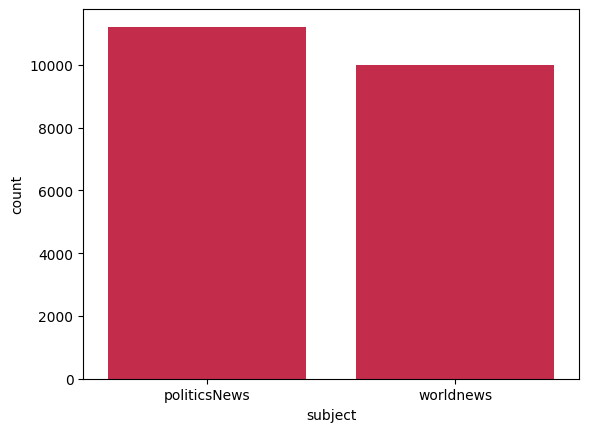

In [18]:
sns.countplot(x=df[df['label']==0]['subject'],color='crimson')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'US_News'),
  Text(1, 0, 'News'),
  Text(2, 0, 'Government News'),
  Text(3, 0, 'left-news'),
  Text(4, 0, 'politics'),
  Text(5, 0, 'Middle-east')])

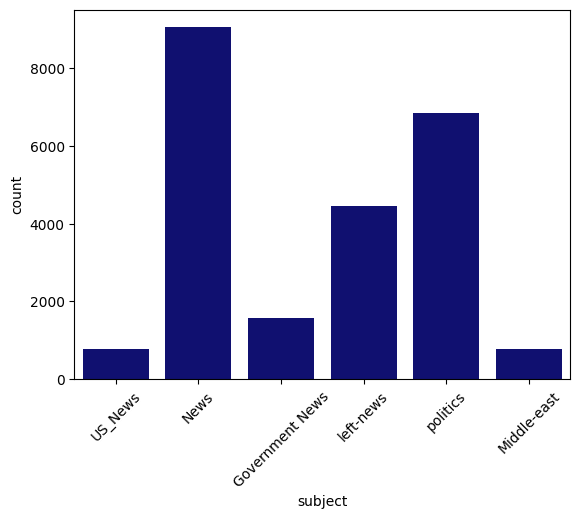

In [19]:
sns.countplot(x=df[df['label']==1]['subject'],color='navy')
plt.xticks(rotation=45)

In [20]:
df['text']=df['title']+" "+df['text']

In [21]:
df['text'].head()

0    Ben Stein Calls Out 9th Circuit Court: Committ...
1    Trump drops Steve Bannon from National Securit...
2    Puerto Rico expects U.S. to lift Jones Act shi...
3     OOPS: Trump Just Accidentally Confirmed He Le...
4    Donald Trump heads for Scotland to reopen a go...
Name: text, dtype: object

In [22]:
import re
import string
def text_preprocess(text):
    # 1. Lowercase (Bilkul sahi)
    text = text.lower()
    text = re.sub(r'\(reuters\)', '', text)
    # 2. URLs hatana (Pehle ye karo, warna punctuation URLs ko tod dega)
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 3. Punctuation hatana
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    
    # 5. Sirf a-z aur spaces rakhna (Extra safety)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 6. Extra spaces hatana (\s+ is correct)
    text = re.sub(r'\s+', ' ', text).strip()
    

    return text

In [23]:
X=df['text']
y=df['label']

In [24]:
X.shape

(44689,)

In [25]:
X.head()

0    Ben Stein Calls Out 9th Circuit Court: Committ...
1    Trump drops Steve Bannon from National Securit...
2    Puerto Rico expects U.S. to lift Jones Act shi...
3     OOPS: Trump Just Accidentally Confirmed He Le...
4    Donald Trump heads for Scotland to reopen a go...
Name: text, dtype: object

In [26]:
X=X.apply(text_preprocess)

In [27]:
X.head()

0    ben stein calls out th circuit court committed...
1    trump drops steve bannon from national securit...
2    puerto rico expects us to lift jones act shipp...
3    oops trump just accidentally confirmed he leak...
4    donald trump heads for scotland to reopen a go...
Name: text, dtype: object

In [28]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords',quiet=True)

True

In [29]:
stop_words=set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [30]:
len(X[X.str.contains('not')])

33383

In [31]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger_eng',quiet=True)
nltk.download('wordnet',quiet=True)
lemmatizer=WordNetLemmatizer()

In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,shuffle=True
)

In [35]:
print(f"Shape of X_train:{X_train.shape}")
print(f"Shape of X_test:{X_test.shape}")


Shape of X_train:(35751,)
Shape of X_test:(8938,)


In [35]:
def get_word_tag_pos(nltk_tag):

    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    else:
        return wordnet.NOUN

def text_lemmatizer(text):
    tokens=word_tokenize(text.lower())
    tokens=[word for word in tokens if word not in stop_words]
    pos_tags=pos_tag(tokens)

    lemmatized=[]
    for word,tag in pos_tags:
        wordnet_pos=get_word_tag_pos(tag)
        lemma=lemmatizer.lemmatize(word,pos=wordnet_pos)
        lemmatized.append(lemma)
    return ' '.join(lemmatized)   

In [1]:
X_train=X_train.apply(text_lemmatizer)
X_test=X_test.apply(text_lemmatizer)

NameError: name 'X_train' is not defined

In [57]:
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer(max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85)
X_train_bow=bow.fit_transform(X_train)
X_test_bow=bow.transform(X_test)

In [58]:
X_train_bow.shape

(35751, 50000)

In [59]:
X_test_bow.shape

(8938, 50000)

 Model : Multinomial NB
Accuracy:0.9643096889684493
Classification_report :
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4286
           1       0.98      0.96      0.97      4652

    accuracy                           0.96      8938
   macro avg       0.96      0.96      0.96      8938
weighted avg       0.96      0.96      0.96      8938



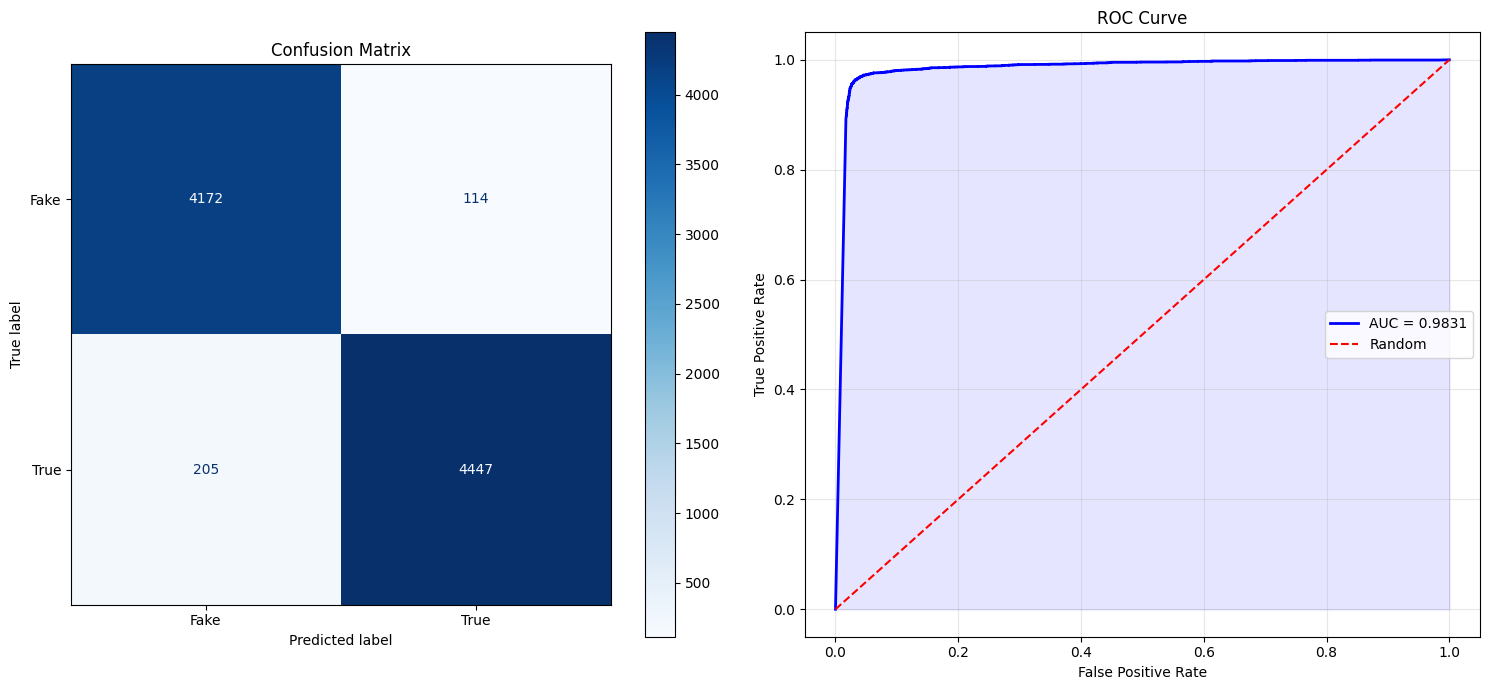

 Model : SVC (Support Vector Machine)


C:\Anaconda\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy:0.993510852539718
Classification_report :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4286
           1       1.00      0.99      0.99      4652

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



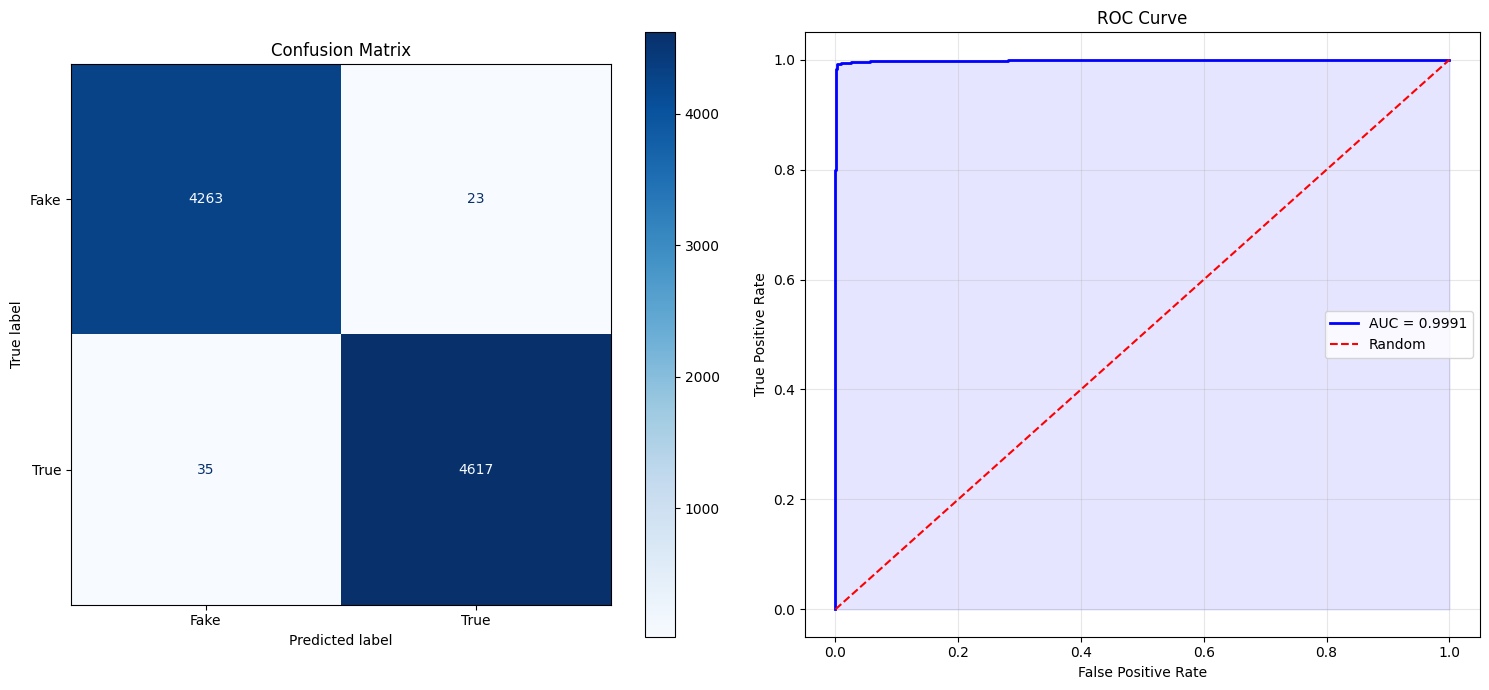

 Model : Random Forest Classifier
Accuracy:0.9809800850302081
Classification_report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4286
           1       0.98      0.98      0.98      4652

    accuracy                           0.98      8938
   macro avg       0.98      0.98      0.98      8938
weighted avg       0.98      0.98      0.98      8938



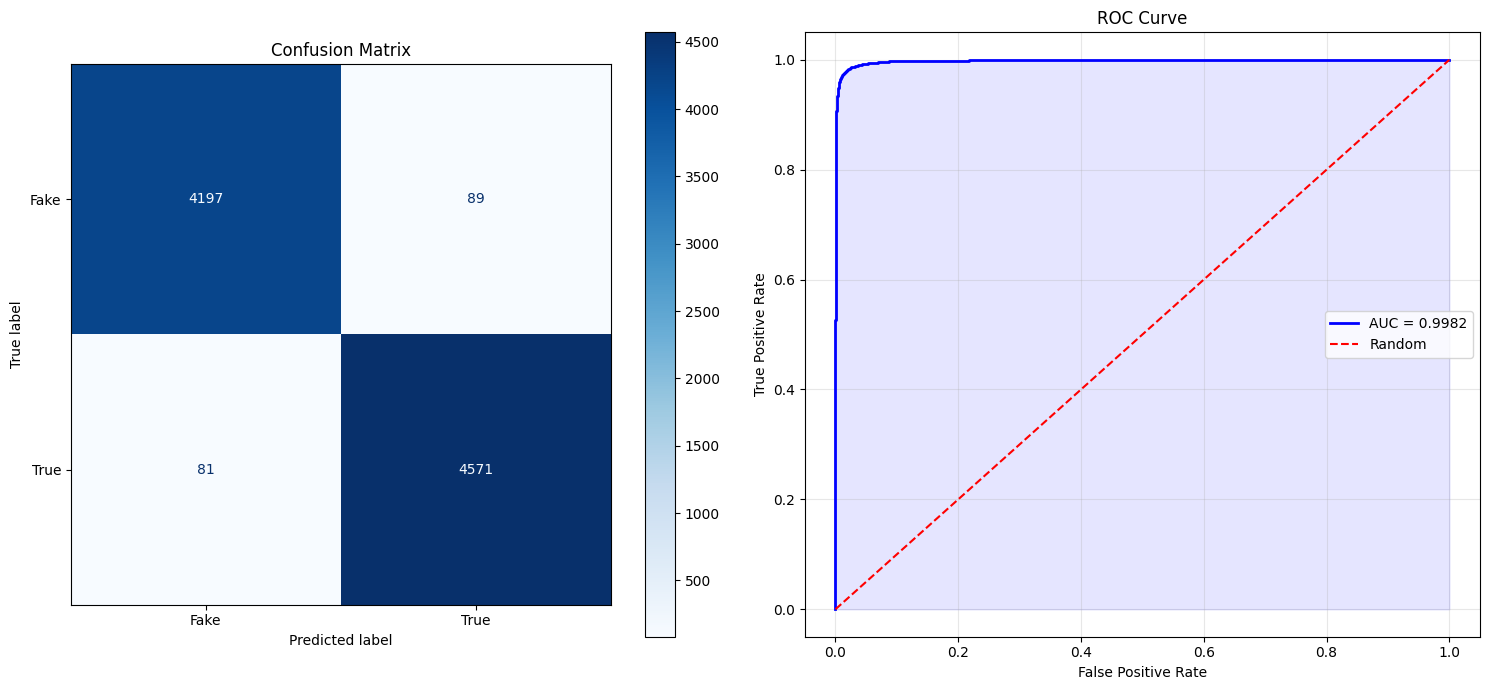

 Model : logistic Regression
Accuracy:0.9956366077422242
Classification_report :
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4286
           1       1.00      0.99      1.00      4652

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



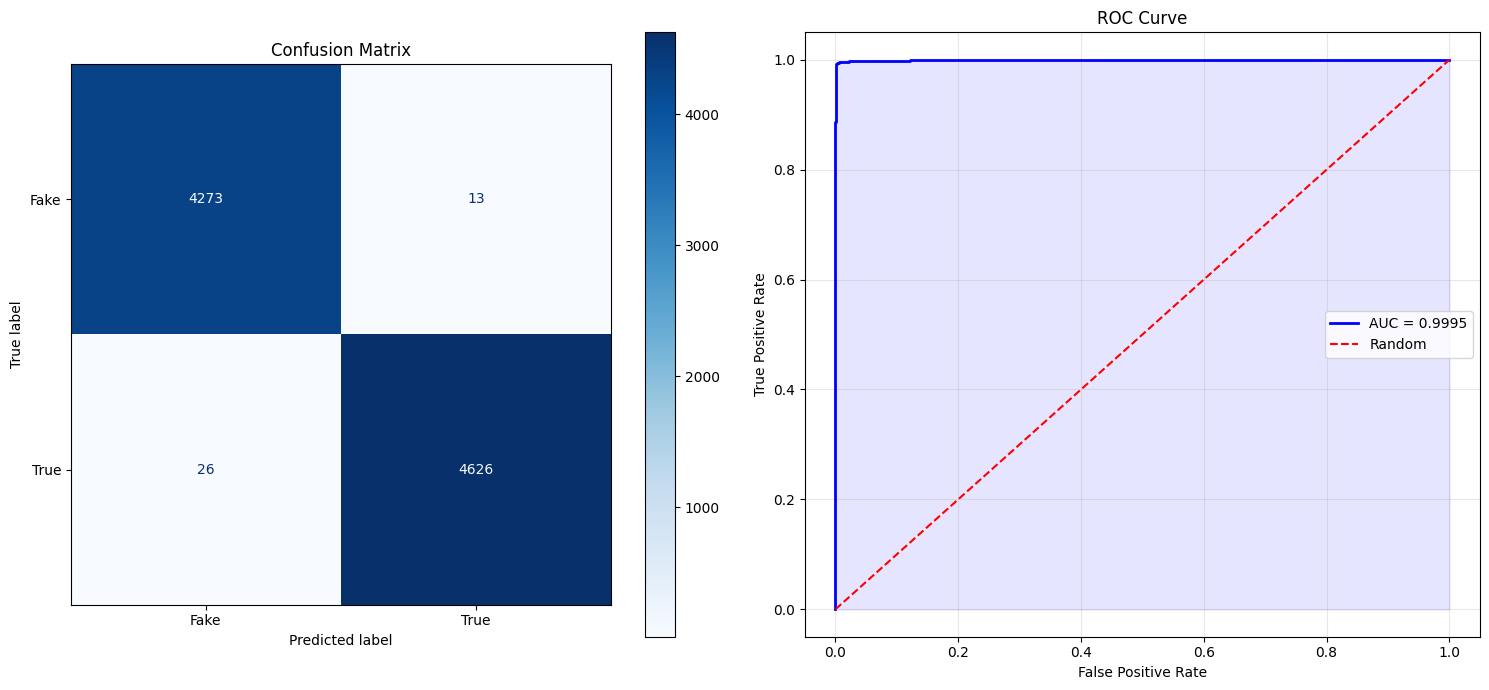

In [60]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, confusion_matrix,precision_score,recall_score,f1_score,
        classification_report,ConfusionMatrixDisplay,roc_auc_score,roc_curve)
models_bow={
    'Multinomial NB':MultinomialNB(),
    'SVC (Support Vector Machine)':CalibratedClassifierCV(LinearSVC(max_iter=10000)),
    'Random Forest Classifier':RandomForestClassifier(  n_estimators=50,  max_depth=20,n_jobs=-1  ),
    "logistic Regression":LogisticRegression(max_iter=1000,class_weight='balanced')
}
acc_bow=[]
f1_bow=[]
recall_bow=[]
precision_bow=[]
labels=['Fake','True']
for name,model in models_bow.items():
    fig,axes=plt.subplots(1,2,figsize=(15,7))
    axes=axes.flatten()
    print(f"="*40)
    print(f" Model : {name}")
    model.fit(X_train_bow,y_train)
    y_pred=model.predict(X_test_bow)
    y_pred_proba=model.predict_proba(X_test_bow)[:,1]
    
    acc=accuracy_score(y_test,y_pred)
    acc_bow.append(acc)

    precision=precision_score(y_test,y_pred)
    precision_bow.append(precision)
    
    recall=recall_score(y_test,y_pred)
    recall_bow.append(recall)
    
    f1=f1_score(y_test,y_pred)
    f1_bow.append(f1)
    
    print(f"Accuracy:{acc}")
    print(f"Classification_report :\n{classification_report(y_test,y_pred)}")
    
    cm=confusion_matrix(y_test,y_pred)
    
    disp=ConfusionMatrixDisplay(cm,display_labels=labels)
    disp.plot(ax=axes[0],cmap='Blues',colorbar=True)
    axes[0].set_title("Confusion Matrix")

    auc=roc_auc_score(y_test,y_pred_proba)
    fpr,tpr,_=roc_curve(y_test,y_pred_proba)
    axes[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0,1], [0,1], 'r--', label='Random')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer( max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

 Model : Multinomial NB
Accuracy:0.9601700604162005
Classification_report :
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4286
           1       0.97      0.95      0.96      4652

    accuracy                           0.96      8938
   macro avg       0.96      0.96      0.96      8938
weighted avg       0.96      0.96      0.96      8938



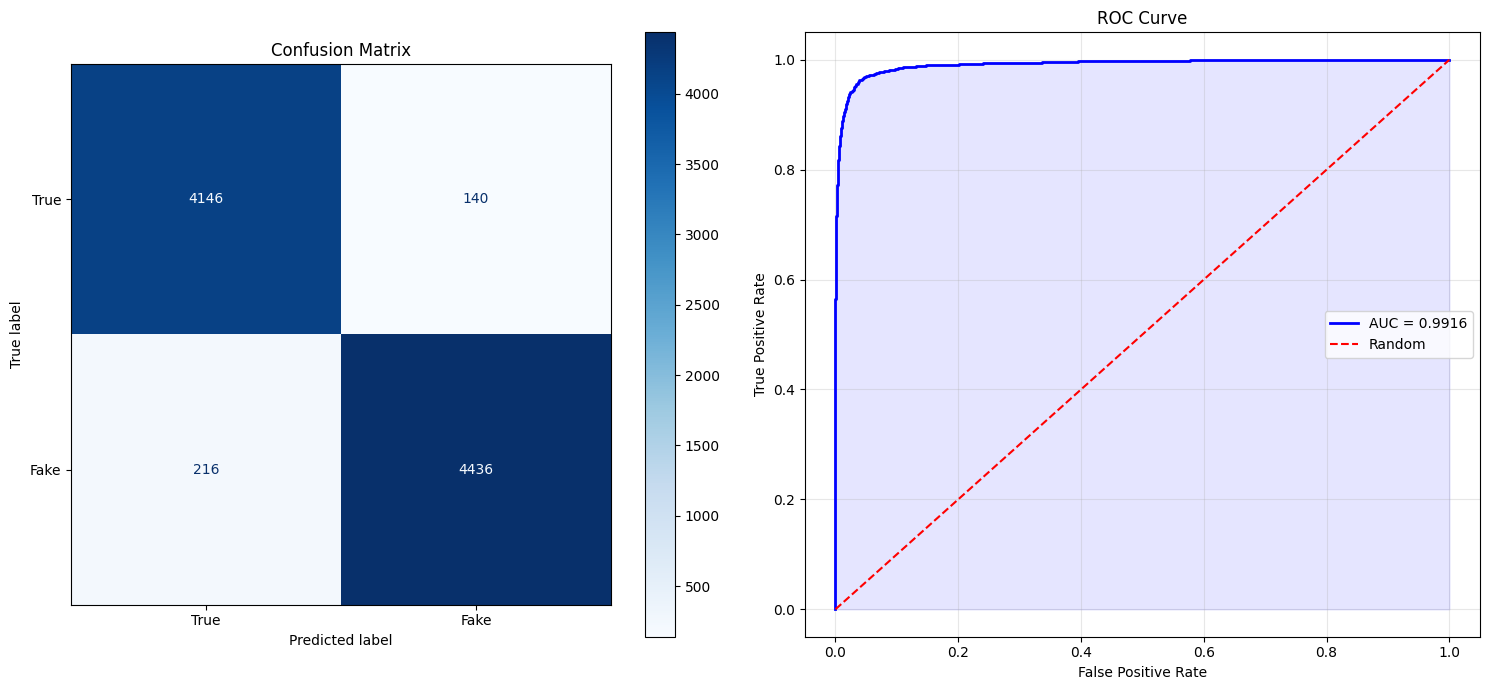

 Model : SVC (Support Vector Machine)
Accuracy:0.9973148355336764
Classification_report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4286
           1       1.00      1.00      1.00      4652

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



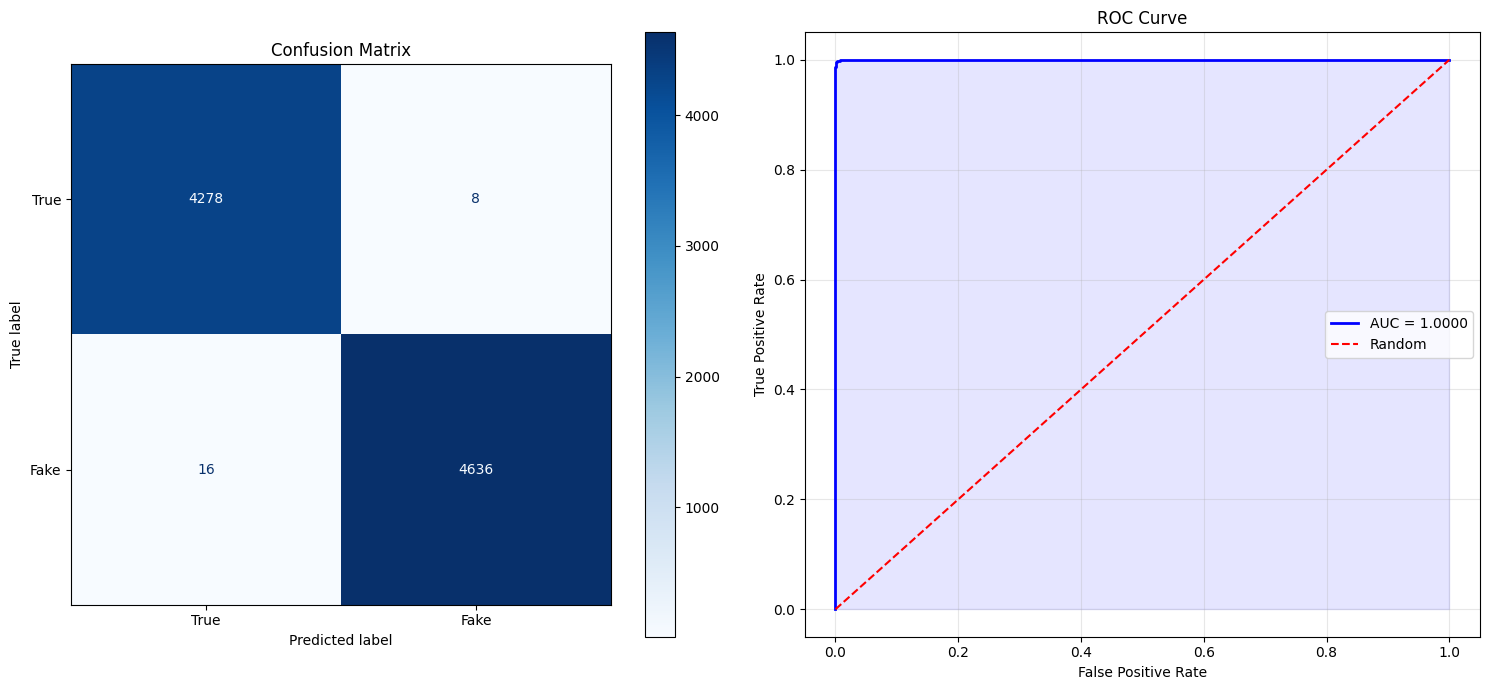

 Model : Random Forest Classifier
Accuracy:0.9824345491161334
Classification_report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4286
           1       0.98      0.98      0.98      4652

    accuracy                           0.98      8938
   macro avg       0.98      0.98      0.98      8938
weighted avg       0.98      0.98      0.98      8938



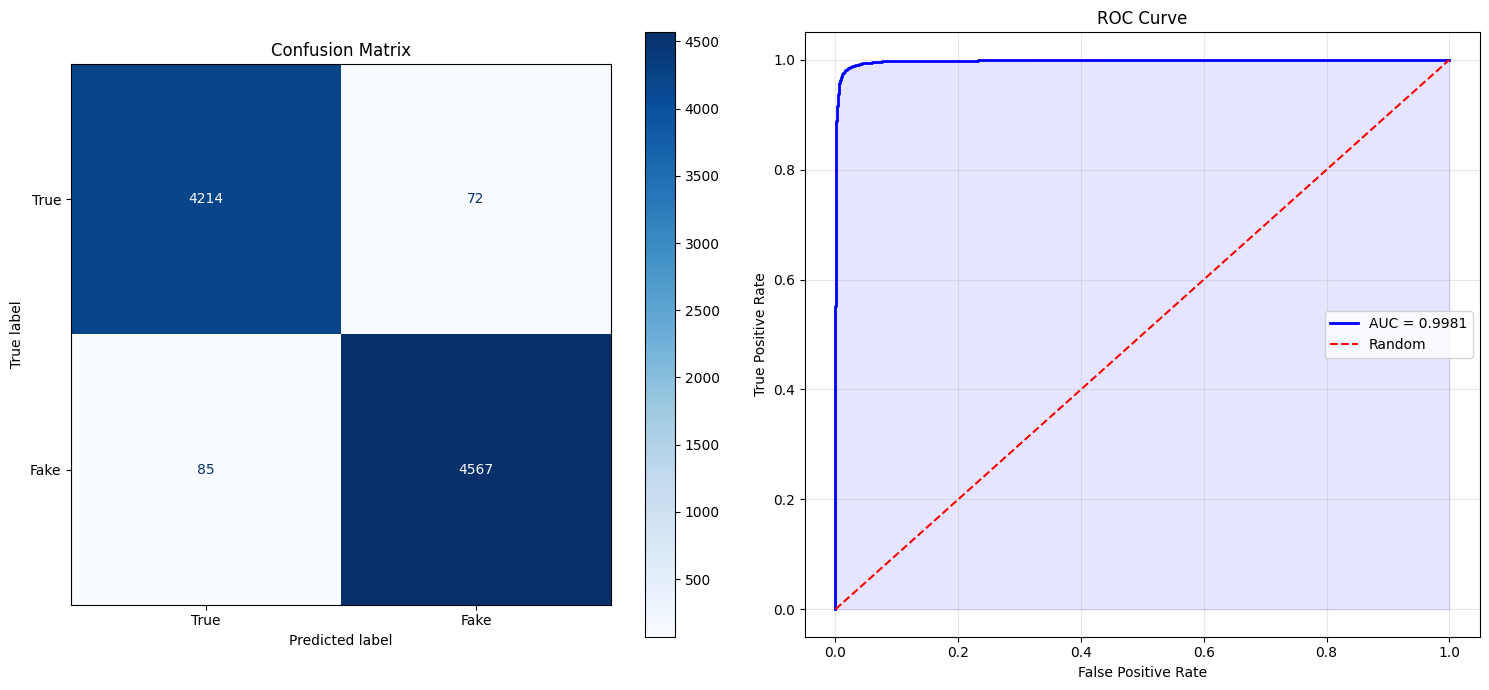

 Model : logistic Regression
Accuracy:0.9918326247482658
Classification_report :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4286
           1       1.00      0.99      0.99      4652

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



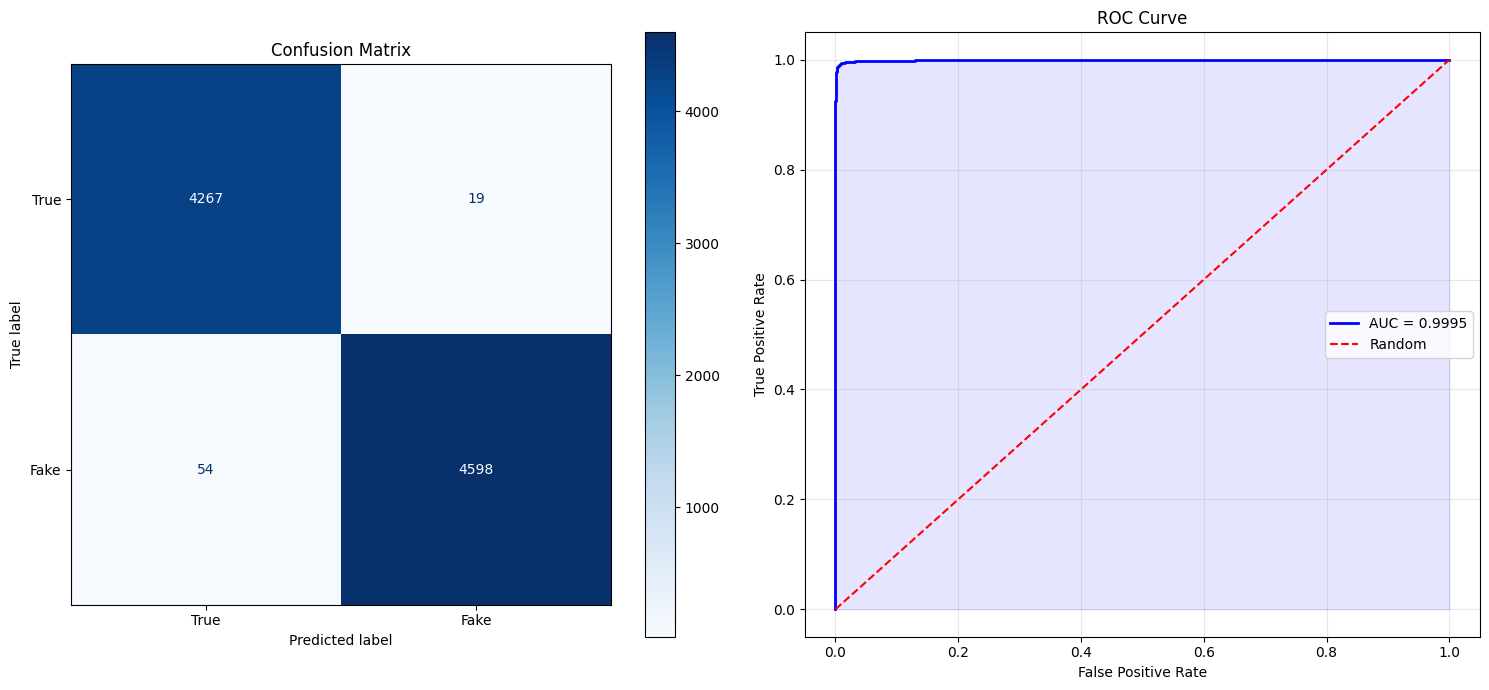

In [62]:
models_tfidf={
    'Multinomial NB':MultinomialNB(),
    'SVC (Support Vector Machine)':CalibratedClassifierCV(LinearSVC(max_iter=10000)),
    'Random Forest Classifier':RandomForestClassifier(  n_estimators=50,  max_depth=20,n_jobs=-1  ),
    "logistic Regression":LogisticRegression(max_iter=1000,class_weight='balanced')
}

labels=['True','Fake']

acc_tfidf=[]
f1_tfidf=[]
recall_tfidf=[]
precision_tfidf=[]

for name,model in models_tfidf.items():
    fig,axes=plt.subplots(1,2,figsize=(15,7))
    axes=axes.flatten()
    print(f"="*40)
    print(f" Model : {name}")
    model.fit(X_train_tfidf,y_train)
    y_pred=model.predict(X_test_tfidf)
    y_pred_proba=model.predict_proba(X_test_tfidf)[:,1]
    
    acc=accuracy_score(y_test,y_pred)
    acc_tfidf.append(acc)

    precision=precision_score(y_test,y_pred)
    precision_tfidf.append(precision)
    
    recall=recall_score(y_test,y_pred)
    recall_tfidf.append(recall)
    
    f1=f1_score(y_test,y_pred)
    f1_tfidf.append(f1)
    print(f"Accuracy:{acc}")
    print(f"Classification_report :\n{classification_report(y_test,y_pred)}")
    
    cm=confusion_matrix(y_test,y_pred)
    
    disp=ConfusionMatrixDisplay(cm,display_labels=labels)
    disp.plot(ax=axes[0],cmap='Blues',colorbar=True)
    axes[0].set_title("Confusion Matrix")

    auc=roc_auc_score(y_test,y_pred_proba)
    fpr,tpr,_=roc_curve(y_test,y_pred_proba)
    axes[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0,1], [0,1], 'r--', label='Random')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

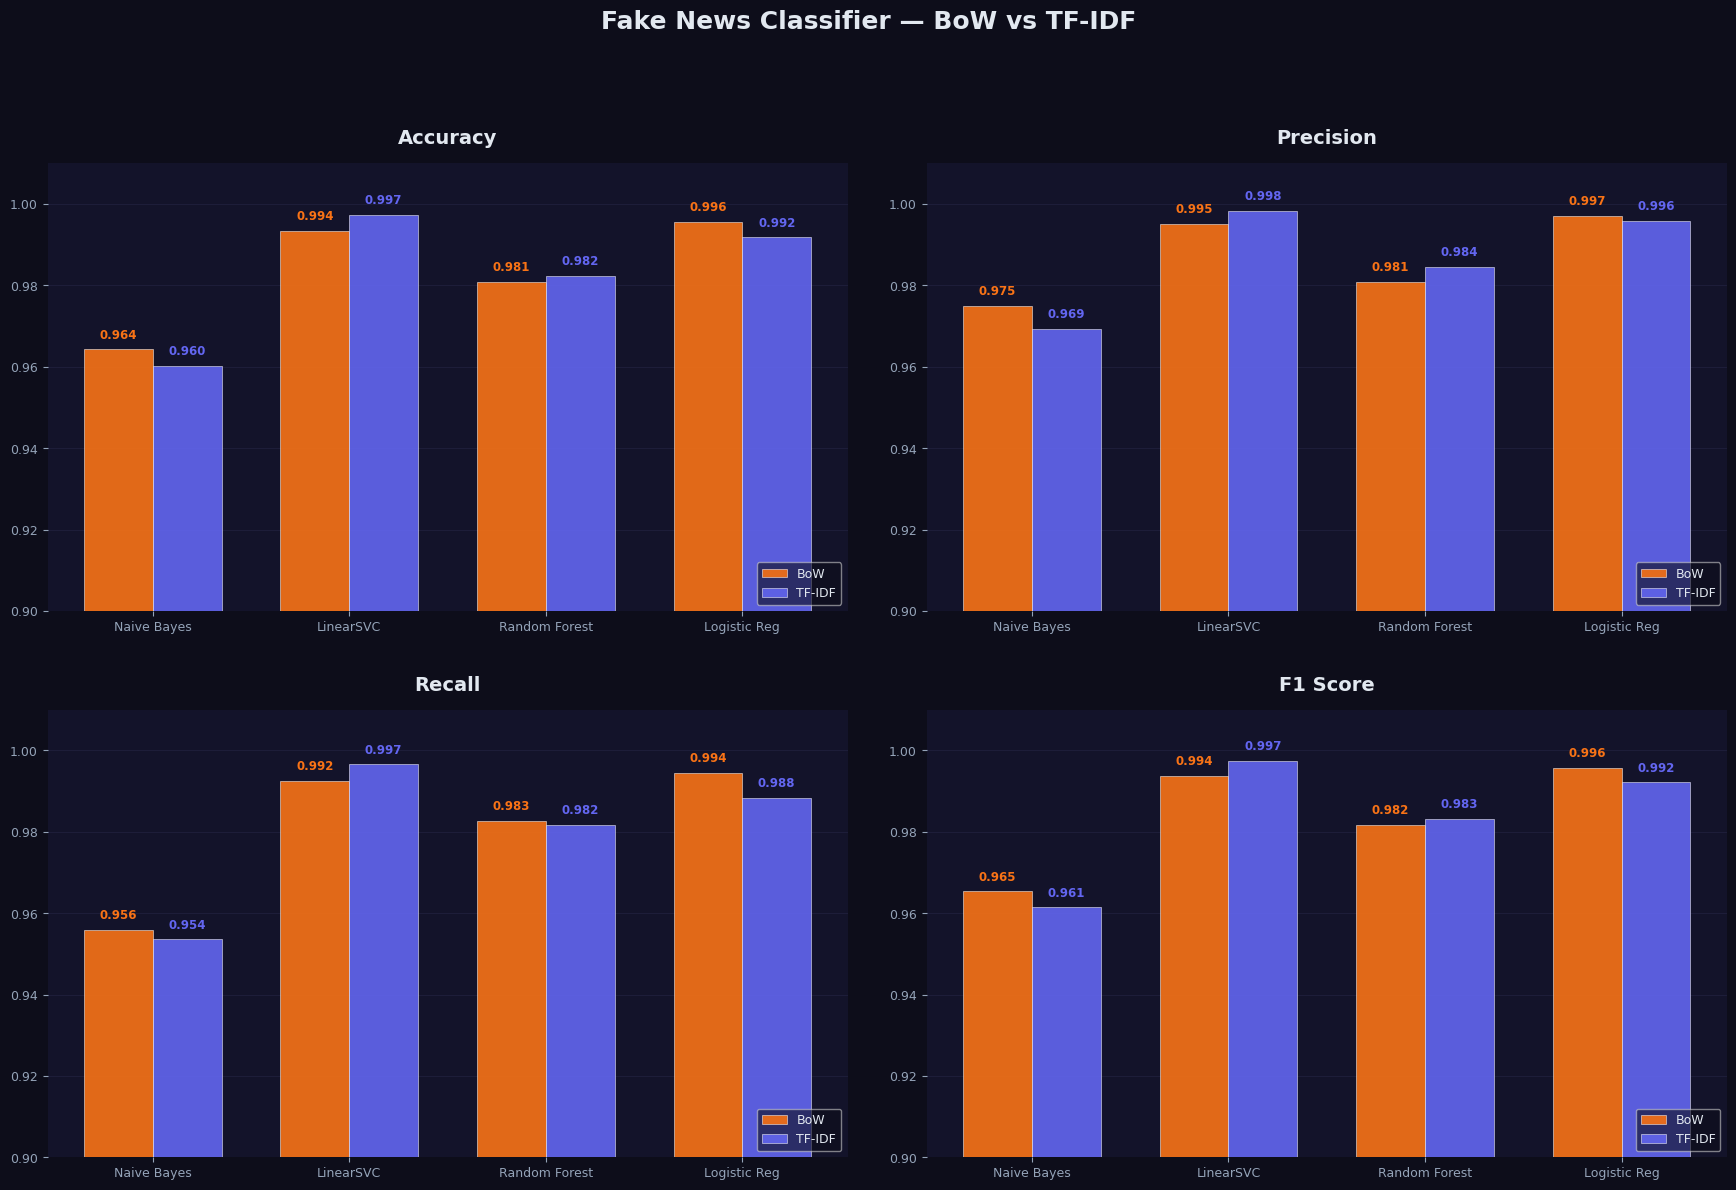

In [63]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────
model_names = ['Naive Bayes', 'LinearSVC', 'Random Forest', 'Logistic Reg']

metrics = {
    'Accuracy':  {'BoW': acc_bow,       'TF-IDF': acc_tfidf},
    'Precision': {'BoW': precision_bow,  'TF-IDF': precision_tfidf},
    'Recall':    {'BoW': recall_bow,     'TF-IDF': recall_tfidf},
    'F1 Score':  {'BoW': f1_bow,         'TF-IDF': f1_tfidf},
}

# ── Style ──────────────────────────────────────────────
BG      = '#0d0d1a'
CARD    = '#13132a'
BOW     = '#f97316'      # orange
TFIDF   = '#6366f1'      # indigo
TEXT    = '#e2e8f0'
MUTED   = '#94a3b8'
GRID    = '#1e1e3a'

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

x     = np.arange(len(model_names))
width = 0.35

for idx, (metric_name, data) in enumerate(metrics.items()):
    ax = axes[idx]
    ax.set_facecolor(CARD)

    # ── Bars ──────────────────────────────────────────
    bars_bow   = ax.bar(x - width/2, data['BoW'],
                        width, color=BOW,
                        alpha=0.9, label='BoW',
                        edgecolor='white', linewidth=0.4,
                        zorder=3)
    bars_tfidf = ax.bar(x + width/2, data['TF-IDF'],
                        width, color=TFIDF,
                        alpha=0.9, label='TF-IDF',
                        edgecolor='white', linewidth=0.4,
                        zorder=3)

    # ── Value Labels on Bars ───────────────────────────
    for bar in bars_bow:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.002,
                f'{h:.3f}',
                ha='center', va='bottom',
                color=BOW, fontsize=8.5,
                fontweight='bold')

    for bar in bars_tfidf:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.002,
                f'{h:.3f}',
                ha='center', va='bottom',
                color=TFIDF, fontsize=8.5,
                fontweight='bold')

    # ── Axes Styling ───────────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(model_names,
                       color=TEXT, fontsize=10)
    ax.set_ylim(0.90, 1.01)
    ax.set_yticks(np.arange(0.90, 1.01, 0.02))
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.yaxis.set_tick_params(labelcolor=MUTED)

    ax.set_title(metric_name,
                 color=TEXT, fontsize=14,
                 fontweight='bold', pad=14)

    # ── Grid ──────────────────────────────────────────
    ax.yaxis.grid(True, color=GRID,
                  linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[:].set_visible(False)

    # ── Legend ────────────────────────────────────────
    ax.legend(facecolor=BG,
              labelcolor=TEXT,
              fontsize=9,
              framealpha=0.6,
              loc='lower right')

# ── Main Title ────────────────────────────────────────
fig.suptitle('Fake News Classifier — BoW vs TF-IDF',
             color=TEXT, fontsize=18,
             fontweight='bold', y=1.01)

plt.tight_layout(pad=3.0)
plt.savefig('model_comparison.png',
            dpi=150, bbox_inches='tight',
            facecolor=BG)
plt.show()